In [594]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [595]:
def generate_data(seq_length = 50, num_samples=1000):
    X = np.linspace(start=0, stop=100, num=num_samples)  # num_samples number between 0-100
    y = np.sin(X) # transform value to radian sinus
    sequence = []
    targets = []

    for i in range(len(X) - seq_length):
        sequence.append(y[i:i+seq_length])
        targets.append(y[i+seq_length])


    plt.figure(figsize=(12,4))
    plt.plot(X, y, label='sin(t)', color='b', linewidth=2)
    plt.title('Sin Wave')
    plt.xlabel('Radian')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.show()

    return np.array(sequence), np.array(targets)

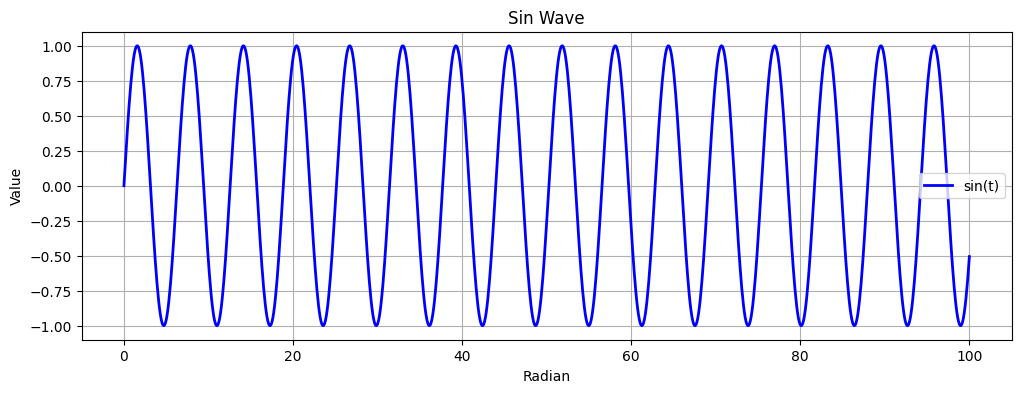

In [596]:
sequence, targets = generate_data()

In [597]:
class RNN(nn.Module):

    def __init__(self, input_size, hidden_size, output_size, num_layers,):
        super(RNN, self).__init__()

        # batch_first=True ----->>>>> (Batch, Sequence, Feature)
        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(in_features=hidden_size, out_features=output_size)

    def forward(self,x):

        out, _ = self.rnn(x)
        out = self.fc(out[:,-1,:])
        return out
        

In [598]:
seq_length = 50
input_size = 1
hidden_size = 16
output_size = 1
num_layers = 1
epochs = 20
batch_size = 32
learning_rate = 0.001

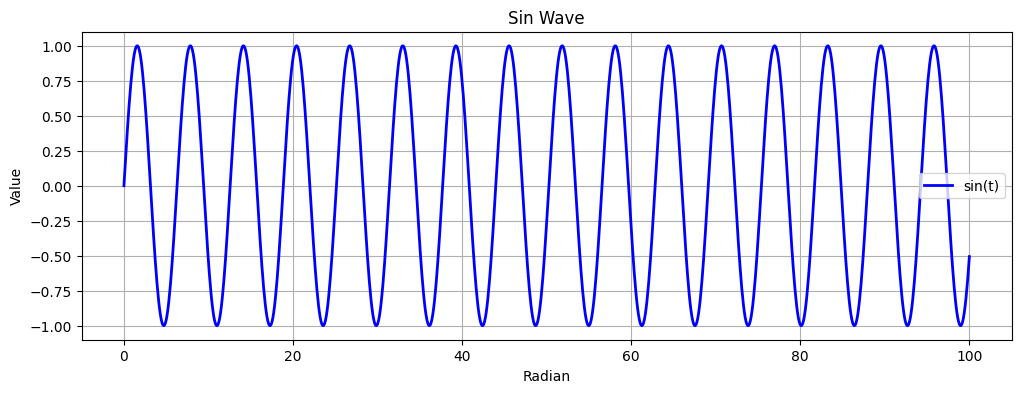

In [599]:
X, y = generate_data(seq_length=seq_length)

In [600]:
print(X.shape)
print(X[0])
print(X[949])
print(y.shape)
print(y[0])
print(y[949])

(950, 50)
[ 0.          0.09993302  0.19886554  0.29580708  0.3897871   0.47986471
  0.56513807  0.64475345  0.71791378  0.7838866   0.84201141  0.89170627
  0.93247368  0.96390547  0.98568695  0.99760007  0.99952556  0.99144412
  0.97343668  0.94568351  0.90846248  0.86214622  0.80719845  0.74416927
  0.67368972  0.59646541  0.51326949  0.42493488  0.33234597  0.23642973
  0.13814643  0.03848005 -0.06157158 -0.16100677 -0.25883002 -0.35406195
 -0.44574912 -0.53297361 -0.61486214 -0.69059488 -0.75941361 -0.82062935
 -0.87362922 -0.91788261 -0.95294646 -0.97846973 -0.99419689 -0.99997048
 -0.9957327  -0.98152597]
[ 0.67959865  0.74950597  0.81190948  0.86618443  0.91178743  0.94826191
  0.97524272  0.99245972  0.99974054  0.9970123   0.9843023   0.9617378
  0.9295447   0.88804531  0.8376551   0.77887857  0.71230417  0.63859842
  0.55849923  0.47280854  0.38238424  0.28813165  0.19099437  0.09194492
 -0.00802505 -0.10791468 -0.2067239  -0.30346347 -0.39716486 -0.48688997
 -0.57174051 -0.

In [601]:
# Batch Size, Sequence Length, Input Size (Feature)

X = torch.tensor(data=X, dtype=torch.float32).unsqueeze(-1)
y = torch.tensor(data=y, dtype=torch.float32).unsqueeze(-1)

In [602]:
print(X.shape)
print(X[0])
print(X[949])
print(y.shape)
print(y[0])
print(y[949])

torch.Size([950, 50, 1])
tensor([[ 0.0000],
        [ 0.0999],
        [ 0.1989],
        [ 0.2958],
        [ 0.3898],
        [ 0.4799],
        [ 0.5651],
        [ 0.6448],
        [ 0.7179],
        [ 0.7839],
        [ 0.8420],
        [ 0.8917],
        [ 0.9325],
        [ 0.9639],
        [ 0.9857],
        [ 0.9976],
        [ 0.9995],
        [ 0.9914],
        [ 0.9734],
        [ 0.9457],
        [ 0.9085],
        [ 0.8621],
        [ 0.8072],
        [ 0.7442],
        [ 0.6737],
        [ 0.5965],
        [ 0.5133],
        [ 0.4249],
        [ 0.3323],
        [ 0.2364],
        [ 0.1381],
        [ 0.0385],
        [-0.0616],
        [-0.1610],
        [-0.2588],
        [-0.3541],
        [-0.4457],
        [-0.5330],
        [-0.6149],
        [-0.6906],
        [-0.7594],
        [-0.8206],
        [-0.8736],
        [-0.9179],
        [-0.9529],
        [-0.9785],
        [-0.9942],
        [-1.0000],
        [-0.9957],
        [-0.9815]])
tensor([[ 0.6796],
     

In [603]:
dataset = torch.utils.data.TensorDataset(X,y)
dataset
#dataset[0-949][0] X
#dataset[0-949][1] Y

In [604]:
print(dataset[0][0])
print("---------------------")
print(dataset[0][1])

tensor([[ 0.0000],
        [ 0.0999],
        [ 0.1989],
        [ 0.2958],
        [ 0.3898],
        [ 0.4799],
        [ 0.5651],
        [ 0.6448],
        [ 0.7179],
        [ 0.7839],
        [ 0.8420],
        [ 0.8917],
        [ 0.9325],
        [ 0.9639],
        [ 0.9857],
        [ 0.9976],
        [ 0.9995],
        [ 0.9914],
        [ 0.9734],
        [ 0.9457],
        [ 0.9085],
        [ 0.8621],
        [ 0.8072],
        [ 0.7442],
        [ 0.6737],
        [ 0.5965],
        [ 0.5133],
        [ 0.4249],
        [ 0.3323],
        [ 0.2364],
        [ 0.1381],
        [ 0.0385],
        [-0.0616],
        [-0.1610],
        [-0.2588],
        [-0.3541],
        [-0.4457],
        [-0.5330],
        [-0.6149],
        [-0.6906],
        [-0.7594],
        [-0.8206],
        [-0.8736],
        [-0.9179],
        [-0.9529],
        [-0.9785],
        [-0.9942],
        [-1.0000],
        [-0.9957],
        [-0.9815]])
---------------------
tensor([-0.9575])


In [605]:
dataLoader = torch.utils.data.DataLoader(dataset=dataset, batch_size=32, shuffle=False)
dataLoader

In [606]:
model = RNN(input_size, hidden_size, output_size, num_layers)

In [607]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [608]:
for epoch in range(epochs):
    for batch_x, batch_y in dataLoader:
        optimizer.zero_grad()
        y_pred = model(batch_x)
        loss = criterion(y_pred, batch_y)
        loss.backward()
        optimizer.step()

    print(f"Epochs: {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epochs: 1/20, Loss: 0.1577
Epochs: 2/20, Loss: 0.0399
Epochs: 3/20, Loss: 0.0188
Epochs: 4/20, Loss: 0.0099
Epochs: 5/20, Loss: 0.0056
Epochs: 6/20, Loss: 0.0032
Epochs: 7/20, Loss: 0.0023
Epochs: 8/20, Loss: 0.0018
Epochs: 9/20, Loss: 0.0015
Epochs: 10/20, Loss: 0.0013
Epochs: 11/20, Loss: 0.0011
Epochs: 12/20, Loss: 0.0009
Epochs: 13/20, Loss: 0.0008
Epochs: 14/20, Loss: 0.0007
Epochs: 15/20, Loss: 0.0006
Epochs: 16/20, Loss: 0.0006
Epochs: 17/20, Loss: 0.0005
Epochs: 18/20, Loss: 0.0005
Epochs: 19/20, Loss: 0.0004
Epochs: 20/20, Loss: 0.0004


In [609]:
## Test ##

X_test = np.linspace(start=100, stop=110, num=seq_length).reshape(-1,1)
y_test = np.sin(X_test)

In [610]:
X_test2 = np.linspace(start=120, stop=130, num=seq_length).reshape(1,-1)
y_test2 = np.sin(X_test2)

In [611]:
X_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(-1)
X_test2 = torch.tensor(y_test2, dtype=torch.float32).unsqueeze(-1)

In [612]:
model.eval()
pred_1 = model(X_test).detach().numpy().flatten()   # shape: (1,)
pred_2 = model(X_test2).detach().numpy().flatten()  # shape: (1,)

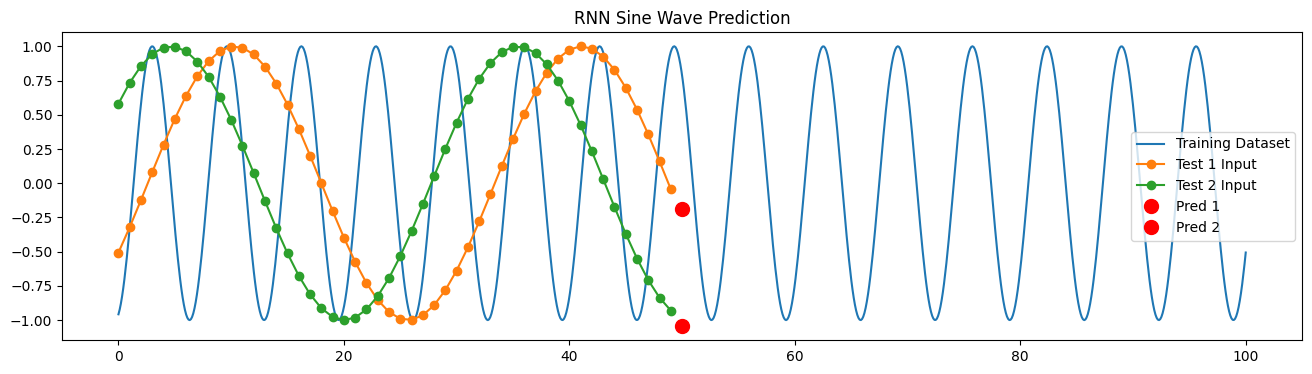

In [ ]:
plt.figure(figsize=(16, 4))
plt.plot(np.linspace(0, 100, len(X)), y.squeeze().detach().numpy(), label="Training Dataset")


plt.plot(np.arange(seq_length), y_test.flatten(),  marker='o', label="Test 1 Input")
plt.plot(np.arange(seq_length), y_test2.flatten(), marker='o', label="Test 2 Input")


plt.plot(seq_length, pred_1[0], "ro", markersize=10, label="Pred 1")
plt.plot(seq_length, pred_2[0], "ro", markersize=10, label="Pred 2")

plt.legend()
plt.title("RNN Sine Wave Prediction")
plt.show()